In [1]:
pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 3.5 MB/s eta 0:00:01
   ------------------------------- -------- 1.3/1.7 MB 3.3 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 2.7 MB/s  0:00:00

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    LSTM,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

import yfinance as yf

In [3]:
df = yf.download(
    'AAPL',
    start='2015-01-01',
    end='2025-01-01'
)

[*********************100%***********************]  1 of 1 completed


In [4]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.192604,24.659506,23.754468,24.648441,212818400
2015-01-05,23.511065,24.042138,23.325190,23.962477,257142000
2015-01-06,23.513279,23.772177,23.152590,23.575237,263188400
2015-01-07,23.842979,23.942555,23.610634,23.721274,160423600
2015-01-08,24.759087,24.816620,24.053201,24.170481,237458000


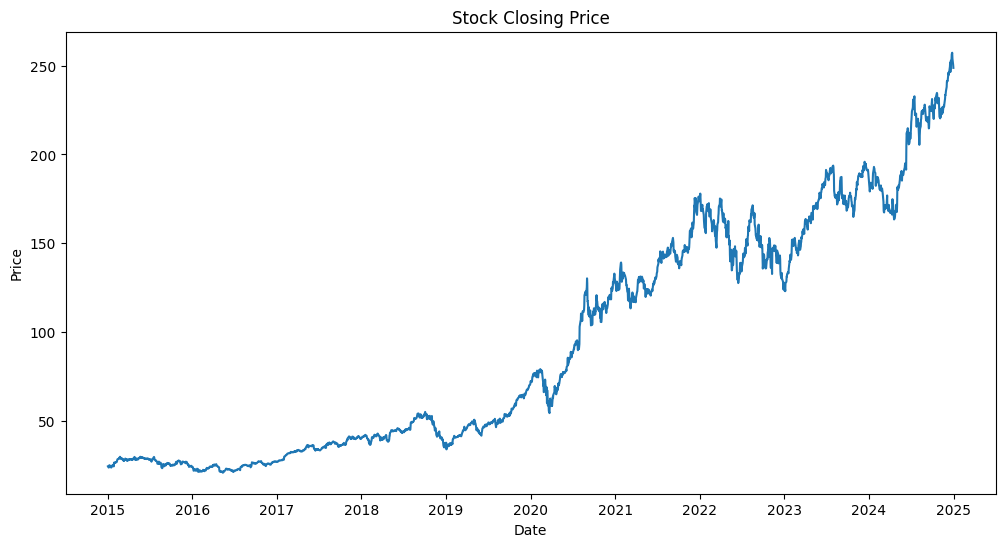

In [5]:
plt.figure(figsize=(12,6))

plt.plot(df['Close'])

plt.title("Stock Closing Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

In [6]:
data = df['Close'].values

In [7]:
scaler = MinMaxScaler(
    feature_range=(0,1)
)

scaled_data = scaler.fit_transform(
    data.reshape(-1,1)
)

In [8]:
X = []
y = []

for i in range(60, len(scaled_data)):
    
    X.append(
        scaled_data[i-60:i,0]
    )
    
    y.append(
        scaled_data[i,0]
    )

X = np.array(X)
y = np.array(y)


In [9]:
X = np.reshape(
    X,
    (X.shape[0], X.shape[1], 1)
)

In [10]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [12]:
model = Sequential([

    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1],1)
    ),

    Dropout(0.2),

    LSTM(64),

    Dropout(0.2),

    Dense(25),

    Dense(1)
])

c:\Users\Puneeth Ram\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.compile(
    optimizer='adam',
    
    loss='mean_squared_error'
)

In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',
    
    patience=3,
    
    restore_best_weights=True
)

In [15]:
history = model.fit(
    X_train,
    y_train,
    
    epochs=20,
    
    batch_size=32,
    
    validation_data=(X_test, y_test),
    
    callbacks=[early_stop]
)

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 145ms/step - loss: 0.0048 - val_loss: 0.0024
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - loss: 8.7349e-04 - val_loss: 6.6293e-04
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - loss: 7.4099e-04 - val_loss: 0.0016
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - loss: 6.4620e-04 - val_loss: 6.1646e-04
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - loss: 7.5379e-04 - val_loss: 8.0825e-04
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - loss: 6.3843e-04 - val_loss: 0.0010
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - loss: 5.5681e-04 - val_loss: 0.0012


In [16]:
predictions = model.predict(X_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step


In [17]:
predictions = scaler.inverse_transform(
    predictions
)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

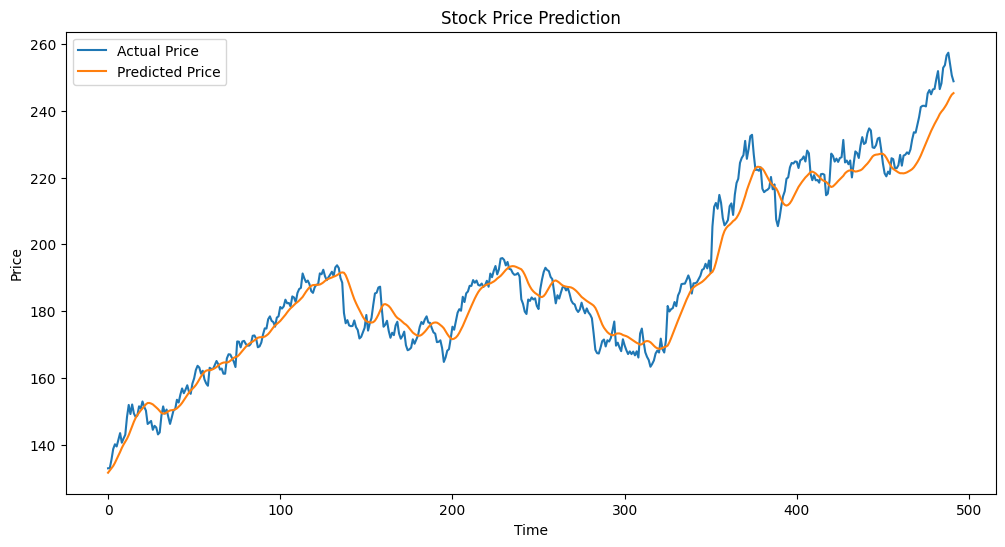

In [18]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test_actual,
    label='Actual Price'
)

plt.plot(
    predictions,
    label='Predicted Price'
)

plt.title("Stock Price Prediction")

plt.xlabel("Time")

plt.ylabel("Price")

plt.legend()

plt.show()

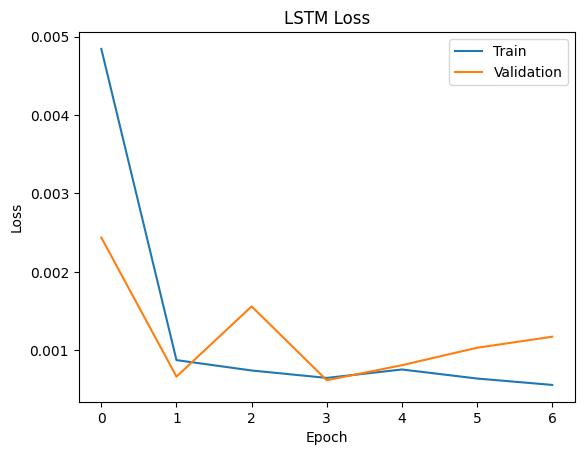

In [19]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("LSTM Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(['Train','Validation'])

plt.show()

In [20]:
model.save(
    "models/lstm_stock_model.h5"
)

In [21]:
last_60_days = scaled_data[-60:]

In [22]:
X_input = []

X_input.append(
    last_60_days[:,0]
)

X_input = np.array(X_input)

In [23]:
X_input = np.reshape(
    X_input,
    (X_input.shape[0],
     X_input.shape[1],
     1)
)

In [24]:
future_prediction = model.predict(X_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


In [25]:
future_prediction = scaler.inverse_transform(
    future_prediction
)

In [26]:
print(
    "Predicted Next Day Stock Price:",
    future_prediction[0][0]
)

Predicted Next Day Stock Price: 245.40593


30-Day Future Stock Price Predictions:

Day 1: 245.4059295654297
Day 2: 245.1270751953125
Day 3: 244.6172637939453
Day 4: 243.97169494628906
Day 5: 243.24867248535156
Day 6: 242.4840087890625
Day 7: 241.6997528076172
Day 8: 240.90945434570312
Day 9: 240.1215057373047
Day 10: 239.34112548828125
Day 11: 238.57122802734375
Day 12: 237.8137664794922
Day 13: 237.06976318359375
Day 14: 236.33970642089844
Day 15: 235.62379455566406
Day 16: 234.92208862304688
Day 17: 234.23440551757812
Day 18: 233.56056213378906
Day 19: 232.9003143310547
Day 20: 232.25335693359375
Day 21: 231.6194305419922
Day 22: 230.99822998046875
Day 23: 230.38943481445312
Day 24: 229.79273986816406
Day 25: 229.2078857421875
Day 26: 228.63455200195312
Day 27: 228.07244873046875
Day 28: 227.5213623046875
Day 29: 226.98097229003906
Day 30: 226.4510498046875


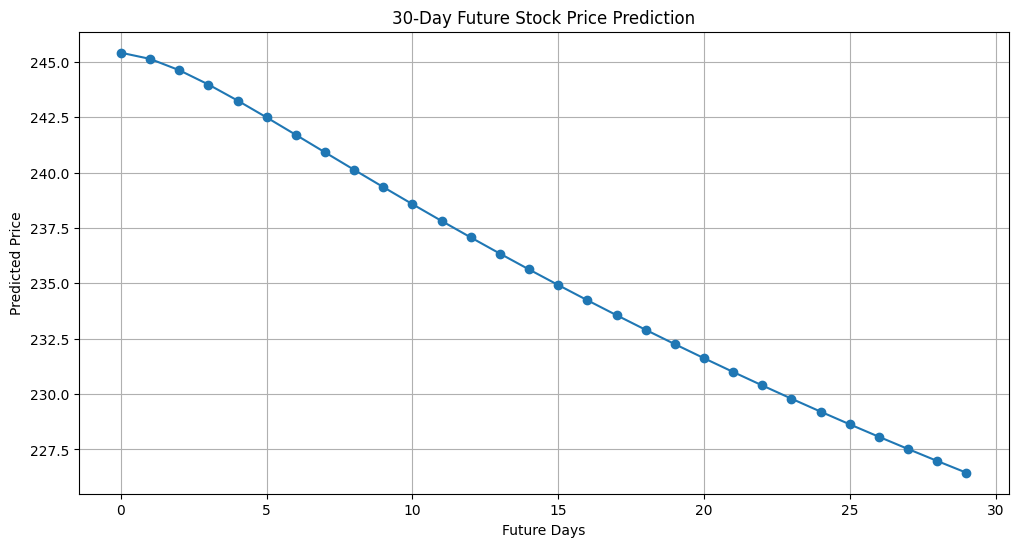

In [31]:
# 30-Day Future Stock Price Prediction

last_60_days = scaled_data[-60:]

future_predictions = []

current_batch = last_60_days.reshape(
    1,
    60,
    1
)

for i in range(30):

    next_prediction = model.predict(
        current_batch,
        verbose=0
    )

    future_predictions.append(
        next_prediction[0][0]
    )

    next_prediction_reshaped = next_prediction.reshape(
        1,
        1,
        1
    )

    current_batch = np.concatenate(
        (
            current_batch[:,1:,:],
            next_prediction_reshaped
        ),
        axis=1
    )

future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

print("30-Day Future Stock Price Predictions:\n")

for i, price in enumerate(future_predictions):

    print(
        f"Day {i+1}: {price[0]}"
    )

plt.figure(figsize=(12,6))

plt.plot(
    future_predictions,
    marker='o'
)

plt.title(
    "30-Day Future Stock Price Prediction"
)

plt.xlabel("Future Days")

plt.ylabel("Predicted Price")

plt.grid(True)

plt.show()